# Chapter 1: The Stochasticity Trap ($\text{Pass}@k$ vs. $\text{Pass}^k$)

When evaluating AI agents across multi-turn tool-calling trajectories, **temperature sampling**, **tool latency**, and **non-deterministic environment states** introduce substantial execution variance. Two metrics capture fundamentally opposite operational goals:

---

## 1. Mathematical Derivations

### A. $\text{Pass}@k$: The Optimistic Capability (Best-of-$k$) Estimator
$\text{Pass}@k$ measures the probability that **at least one** out of $k$ independent rollouts succeeds on a task. If a task has true latent success probability $p_i$, then theoretically:
$$\text{Pass}@k_i = 1 - (1 - p_i)^k$$

Directly computing $1 - (1 - \hat{p}_i)^k$ from a small sample produces severe upward variance. Instead, **Chen et al. (2021)** derived the **unbiased combinatorial estimator** by drawing $n \ge k$ total trials per task and counting $c$ successes:
$$\widehat{\text{Pass}@k} = 1 - \frac{\binom{n - c}{k}}{\binom{n}{k}}$$

*Why is it unbiased?* The term $\frac{\binom{n - c}{k}}{\binom{n}{k}}$ is the exact hypergeometric probability of drawing $k$ failures out of $n$ trials when $n - c$ failures exist. Its expectation over $c \sim \text{Binomial}(n, p_i)$ is $(1 - p_i)^k$.

---

### B. $\text{Pass}^k$: The Consistency & Production Reliability Estimator
Introduced in **$\tau$-bench (Yao et al., 2024)**, $\text{Pass}^k$ measures the probability that **all $k$** independent rollouts succeed on the task:
$$\text{Pass}^k_i = p_i^k$$

Using the same $n$ trials and $c$ successes ($k \le n$), the **unbiased combinatorial estimator** for $p_i^k$ is the probability that a random subset of size $k$ drawn without replacement contains **only successes**:
$$\widehat{\text{Pass}^k}_{\text{unbiased}} = \frac{\binom{c}{k}}{\binom{n}{k}}, \qquad \widehat{\text{Pass}^k}_{\text{plugin}} = \left(\frac{c}{n}\right)^k$$

> **The Trap**: As $k \to \infty$, $\text{Pass}@k$ monotonically **inflates** toward $1.0$ for any flaky agent ($p_i > 0$), whereas $\text{Pass}^k$ exponentially **decays** toward $0.0$ unless $p_i \approx 1.0$. Relying on $\text{Pass}@k$ (or single-seed $\text{Pass}@1$) masks catastrophic production flakiness!

## 🧠 Layman's Guide: The Blindfolded Dart Thrower vs. The Precision Archer

![Chapter 1: The Stochasticity Trap (`Pass@k` vs. `Pass^k`) — Concept Illustration](./figures/concepts/ch01_concept.jpg)

Imagine you are hiring an archer to protect a castle, and you give two candidates **5 arrows** each:

- **Candidate A (The Lucky Gambler — Measured by `Pass@k`)**: Throws 5 arrows wildly while spinning around. Four arrows fly into the stands, and **one lucky arrow hits the bullseye**. If your grading rule is *"Did at least one arrow out of 5 hit the target?"* (`Pass@5`), Candidate A gets a **100% score!**
- **Candidate B (The Precision Master — Measured by `Pass^k`)**: Calmly aims and lands **all 5 arrows** tightly inside the bullseye ring every single time. If your grading rule is *"Did ALL 5 arrows hit the target without a single miss?"* (`Pass^5`), only Candidate B passes.

### Why This Matters for AI Agents
Large Language Models (LLMs) are **stochastic** (non-deterministic)—even with the exact same prompt, slight sampling randomness or tool-timing differences can cause an agent to take a different reasoning path on each run:
- **`Pass@k` ("Try-Until-You-Win")** is great when you have an automated verifier—for example, an AI coding assistant that generates 5 candidate patches, runs your unit test suite on all 5, and only shows the user the 1 patch that passed.
- **`Pass^k` ("Zero-Defect Consistency")** is essential when an agent interacts directly with a live customer, executes a financial transaction, or modifies a database where **there is no undo button**. An agent that succeeds 75% of the time on 1 try (`Pass@1 = 75%`) will succeed 5 times in a row only $0.75^5 \approx 23.7\%$ of the time (`Pass^5 = 23.7%`)!

---

### 🧗 Why This Matters for Agentic Hill-Climbing
> **Hill-Climbing Role**: *Stage 1 — Defining the Hill's Objective Function (Climbing True Altitude vs. Climbing Noise)*

In **Agentic Hill-Climbing**, an automated optimizer iteratively mutates your system prompt or tool definitions, scores the candidate against your benchmark, and keeps the mutation if the score goes up. **The metric you choose defines the "altitude" of the hill:**

- **What Breaks Without It (Climbing Execution Noise)**: If your hill-climber evaluates each prompt mutation using only a single seed (`Pass@1`) or optimizes `Pass@k` for a customer-facing agent, the optimizer will **mistake a lucky coin flip for a genuine improvement**. In our simulation, a chaotic/high-variance prompt gets lucky on a single run (`Pass@1 = 76%`) and tricks the hill-climber into replacing a rock-solid baseline (`Pass@1 = 74%`). Beneath the surface, that "upgrade" caused 5-run reliability (`Pass^5`) to crash from **66% down to 26%**!
- **How It Supercharges the Hill-Climber**:
  1. **Multi-Seed Evaluation ($n$ seeds per task)** smooths out trajectory variance so the hill-climber doesn't chase phantom 2% bumps caused by random LLM sampling.
  2. **Objective Alignment**: Using $\widehat{\text{Pass}@k}$ when hill-climbing a **verifier-backed coding harness** (where best-of-$k$ sampling is used at inference time) versus $\widehat{\text{Pass}^k}$ when hill-climbing an **autonomous transactional agent** guarantees that every accepted step up the hill improves real production reliability.

---

### 📖 Plain-English Terminology & Jargon Buster

| Term / Symbol | Plain-English Meaning |
| :--- | :--- |
| **Stochasticity** | Randomness in how an agent behaves from run to run, even when given the exact same task and prompt. |
| **Seed / Trial ($n$)** | One complete, independent attempt by the agent to solve a task from start to finish. |
| **`Pass@1`** | The basic success rate when you only run the agent once per task. |
| **`Pass@k` (Optimistic Capability)** | The probability that the agent solves the task **at least once** if given $k$ attempts. As $k$ grows, `Pass@k` goes **up**. |
| **`Pass^k` (Production Consistency)** | The probability that the agent solves the task **every single time** across $k$ back-to-back attempts. As $k$ grows, `Pass^k` goes **down**. |
| **Consistency Delta ($\text{Pass}@1 - \text{Pass}^k$)** | How much an agent's reliability drops when you require $k$ consecutive successes instead of just 1. A large delta means the agent is 'flaky'. |
| **Binomial Coefficient $\binom{n}{k}$** | Read as '$n$ choose $k$'—the total number of ways to pick $k$ runs out of $n$ recorded trials without caring about order. |

### 📚 Resources & Deeper Reading
- **Chen, M., Tworek, J., Jun, H., et al. (2021).** *Evaluating Large Language Models Trained on Code (HumanEval).* arXiv:2107.03374. [https://arxiv.org/abs/2107.03374](https://arxiv.org/abs/2107.03374) — Introduces the unbiased combinatorial $\text{Pass}@k$ estimator.
- **Yao, S., Shinn, N., Razavi, P., & Narasimhan, K. (2024).** *$\tau$-bench: A Benchmark for Tool-Agent-User Interaction in Real-World Domains.* arXiv:2406.12045. [https://arxiv.org/abs/2406.12045](https://arxiv.org/abs/2406.12045) — Introduces $\text{Pass}^k$ ($\text{pass}\text{^}k$) to measure enterprise agent reliability across repeated trials.
- **Kapoor, S., Stroebl, B., Siegel, Z. S., Nadgir, N., & Narayanan, A. (2024).** *AI Agents That Matter.* arXiv:2407.01502. [https://arxiv.org/abs/2407.01502](https://arxiv.org/abs/2407.01502) — Discusses cost-controlled and variance-aware agent evaluation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import comb

from agent_stats.ch01_stochasticity import (
    AgentStochasticitySimulator,
    calculate_pass_at_k,
    calculate_pass_pow_k,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120
print("Loaded Chapter 1 Stochasticity Engine successfully.")

Loaded Chapter 1 Stochasticity Engine successfully.


## 2. Simulation Engine & Metric Implementations

Below we instantiate `AgentStochasticitySimulator` across $N=200$ benchmark tasks and $n=20$ repeated seeds per task, comparing three distinct agent profiles:
1. **Consistent Deterministic Agent**: Baseline capability $= 75\%$, Low execution noise ($\sigma = 0.12$).
2. **Moderate Production Agent**: Baseline capability $= 75\%$, Moderate execution noise ($\sigma = 0.45$).
3. **Lucky Flaky Agent**: Baseline capability $= 75\%$, High execution noise ($\sigma = 0.85$).

Notice that **all three agents have the exact same $\text{Pass}@1 \approx 75\%$!**

In [2]:
sim = AgentStochasticitySimulator(num_tasks=200, num_seeds=20, random_state=42)

profiles = [
    sim.simulate_agent("Consistent Deterministic Agent (noise=0.12)", baseline_capability=0.75, execution_noise=0.12, seed_offset=1),
    sim.simulate_agent("Moderate Production Agent (noise=0.45)", baseline_capability=0.75, execution_noise=0.45, seed_offset=2),
    sim.simulate_agent("Lucky Flaky Agent (noise=0.85)", baseline_capability=0.75, execution_noise=0.85, seed_offset=3),
]

k_vals = list(range(1, 11))
summary_rows = []
for prof in profiles:
    p_at_k = prof.pass_at_k_curve(k_vals)
    p_pow_k = prof.pass_pow_k_curve(k_vals)
    summary_rows.append({
        "Agent Profile": prof.name,
        "Pass@1": f"{p_at_k[0]:.1%}",
        "Pass@5": f"{p_at_k[4]:.1%}",
        "Pass@10": f"{p_at_k[9]:.1%}",
        "Pass^5 (5-in-a-row)": f"{p_pow_k[4]:.1%}",
        "Pass^10 (10-in-a-row)": f"{p_pow_k[9]:.1%}",
        "Consistency Delta (Pass@1 - Pass^5)": f"{(p_at_k[0] - p_pow_k[4]):.1%}",
    })

pd.DataFrame(summary_rows)

,Agent Profile,Pass@1,Pass@5,Pass@10,Pass^5 (5-in-a-row),Pass^10 (10-in-a-row),Consistency Delta (Pass@1 - Pass^5)
0,Consistent Deterministic Agent (noise=0.12),75.0%,82.2%,84.4%,67.1%,64.2%,7.9%
1,Moderate Production Agent (noise=0.45),75.5%,85.6%,88.4%,63.0%,57.2%,12.5%
2,Lucky Flaky Agent (noise=0.85),74.8%,95.5%,98.2%,43.9%,31.4%,30.9%


## 3. Visualizations: $\text{Pass}@k$ vs. $\text{Pass}^k$ Divergence & Consistency Delta Heatmap

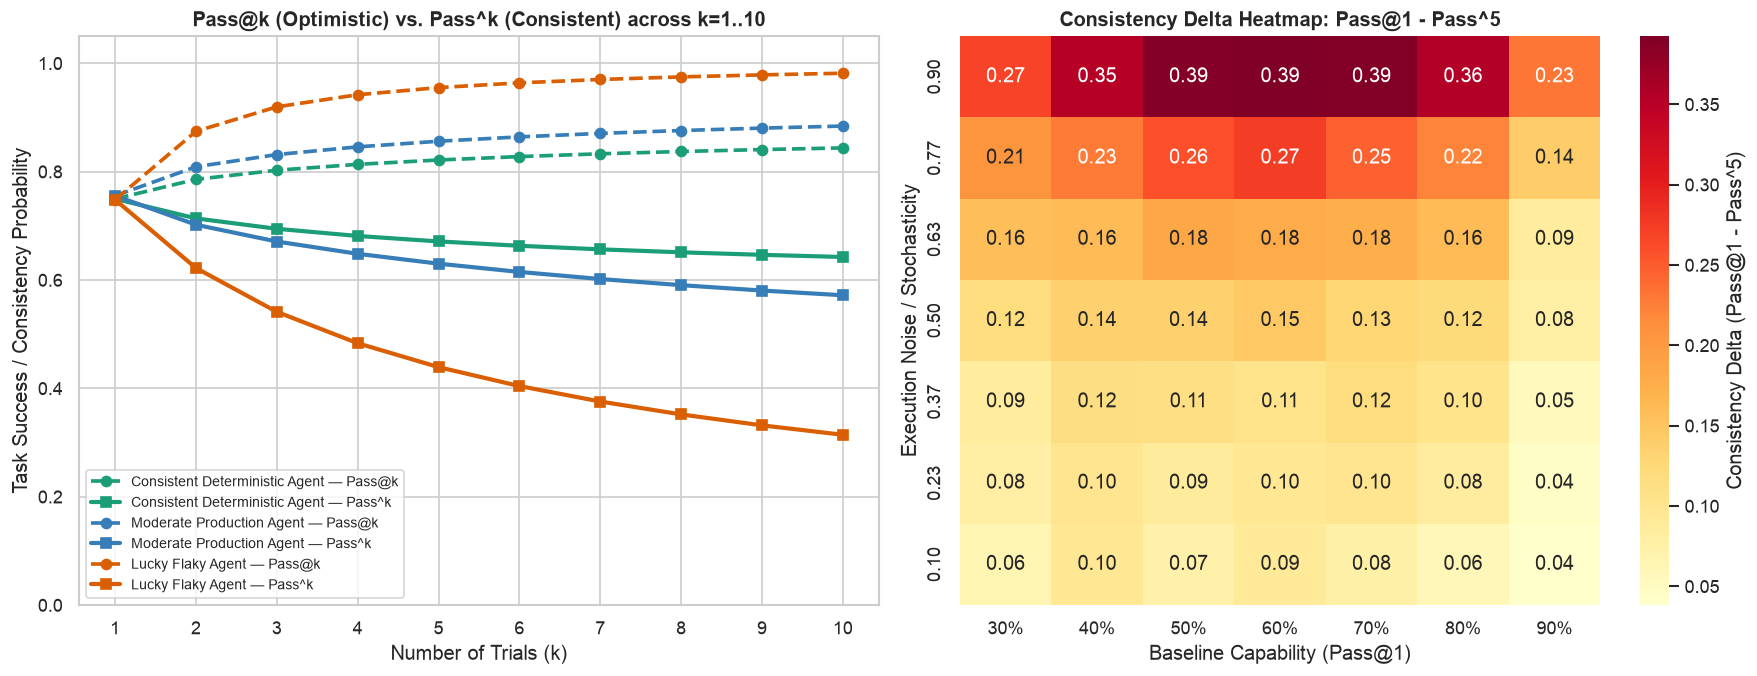

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

# Plot 1: Pass@k vs Pass^k curves for k = 1..10
colors = ["#1b9e77", "#377eb8", "#d95f02"]
for prof, color in zip(profiles, colors):
    p_at_k = prof.pass_at_k_curve(k_vals)
    p_pow_k = prof.pass_pow_k_curve(k_vals)
    axes[0].plot(k_vals, p_at_k, marker="o", linestyle="--", color=color, linewidth=2.2, label=f"{prof.name.split(' (')[0]} — Pass@k")
    axes[0].plot(k_vals, p_pow_k, marker="s", linestyle="-", color=color, linewidth=2.5, label=f"{prof.name.split(' (')[0]} — Pass^k")

axes[0].set_title("Pass@k (Optimistic) vs. Pass^k (Consistent) across k=1..10", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Trials (k)")
axes[0].set_ylabel("Task Success / Consistency Probability")
axes[0].set_xticks(k_vals)
axes[0].set_ylim(0.0, 1.05)
axes[0].legend(fontsize=8.5, loc="lower left")

# Plot 2: Heatmap of Consistency Delta (Pass@1 - Pass^5) across noise & baseline capability
capabilities = np.linspace(0.30, 0.90, 7)
noise_levels = np.linspace(0.10, 0.90, 7)
delta_grid = sim.consistency_delta_grid(capabilities, noise_levels, k=5)

sns.heatmap(
    delta_grid,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    xticklabels=[f"{c:.0%}" for c in capabilities],
    yticklabels=[f"{n:.2f}" for n in noise_levels],
    cbar_kws={"label": "Consistency Delta (Pass@1 - Pass^5)"},
    ax=axes[1],
)
axes[1].set_title("Consistency Delta Heatmap: Pass@1 - Pass^5", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Baseline Capability (Pass@1)")
axes[1].set_ylabel("Execution Noise / Stochasticity")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("figures/ch01_pass_at_k_vs_pass_pow_k.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Interactive Hands-on Exercise: Choosing Between Two Prompt Variants

Suppose you are evaluating two candidate system prompts for a production customer-support agent:
- **Prompt Variant A ("Aggressive Explorer")**: Mean capability $= 76\%$, but high temperature/tool-selection variance (`execution_noise = 0.80`).On a single lucky seed, it can spike up to **79.5% $\text{Pass}@1$**.
- **Prompt Variant B ("Structured Deterministic")**: Mean capability $= 74\%$, with strict schema constraints (`execution_noise = 0.10`).

Let's simulate how a developer running a **single-seed $\text{Pass}@1$ eval** gets tricked into shipping Prompt A, whereas a **$k=5$ $\text{Pass}^k$ consistency check** exposes Prompt A's catastrophic flakiness ($26\%$ $\text{Pass}^5$ vs. $66\%$ for Prompt B).

In [4]:
prompt_a = sim.simulate_agent("Prompt A (High-Variance Explorer)", baseline_capability=0.76, execution_noise=0.80, seed_offset=101)
prompt_b = sim.simulate_agent("Prompt B (Structured Deterministic)", baseline_capability=0.74, execution_noise=0.10, seed_offset=202)

# Single-run Pass@1 on Seed #0
seed0_a = prompt_a.trial_matrix[:, 0].mean()
seed0_b = prompt_b.trial_matrix[:, 0].mean()

# Multi-seed Unbiased Pass@5 and Pass^5 across n=20 seeds
pass_at_5_a = np.mean(calculate_pass_at_k(20, prompt_a.success_counts, 5))
pass_at_5_b = np.mean(calculate_pass_at_k(20, prompt_b.success_counts, 5))
pass_pow_5_a = np.mean(calculate_pass_pow_k(20, prompt_a.success_counts, 5))
pass_pow_5_b = np.mean(calculate_pass_pow_k(20, prompt_b.success_counts, 5))

print("=== HANDS-ON PROMPT SELECTION AUDIT ===")
print(f"Single-Run Pass@1 (Seed 0) -> Prompt A: {seed0_a:.1%} | Prompt B: {seed0_b:.1%}")
print(f"  [Naive Decision]: Picks {'Prompt A' if seed0_a > seed0_b else 'Prompt B'} based on a single eval run!")
print("-" * 65)
print(f"Unbiased Pass@5 (Best of 5) -> Prompt A: {pass_at_5_a:.1%} | Prompt B: {pass_at_5_b:.1%}")
print(f"Unbiased Pass^5 (5/5 Rel.)  -> Prompt A: {pass_pow_5_a:.1%} | Prompt B: {pass_pow_5_b:.1%}")
print(f"  [Production Decision]: Picks {'Prompt B' if pass_pow_5_b > pass_pow_5_a else 'Prompt A'} (+{(pass_pow_5_b - pass_pow_5_a)*100:.1f} pp higher 5-run reliability!)")

=== HANDS-ON PROMPT SELECTION AUDIT ===
Single-Run Pass@1 (Seed 0) -> Prompt A: 76.5% | Prompt B: 75.0%
  [Naive Decision]: Picks Prompt A based on a single eval run!
-----------------------------------------------------------------
Unbiased Pass@5 (Best of 5) -> Prompt A: 94.3% | Prompt B: 80.5%
Unbiased Pass^5 (5/5 Rel.)  -> Prompt A: 51.5% | Prompt B: 66.1%
  [Production Decision]: Picks Prompt B (+14.6 pp higher 5-run reliability!)
